#Import dan Load Data

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)

In [ ]:
df = pd.read_csv(
    "StudentPerformanceFactors.csv")
print(
    f"Rows : {df.shape[0]}")
print(
    f"Columns : {df.shape[1]}")
display(df.head())

Rows : 6607
Columns : 20


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


#Data Understanding

In [ ]:
# Dataset information

df.info()
print("\nData Types")
display(df.dtypes.to_frame("Data Type"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

,Data Type
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64


In [ ]:
# Missing values and duplicate data

missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage (%)": round(df.isnull().mean() * 100, 2)
})
display(
    missing_values.sort_values(
        by="Missing Count",
        ascending=False))
print(f"\nDuplicate Rows : {df.duplicated().sum()}")
print("\nTotal Missing Values :", df.isnull().sum().sum()
)
print("Missing Percentage :",round(df.isnull().sum().sum()/
        (df.shape[0] * df.shape[1])* 100,2),"%")

,Missing Count,Missing Percentage (%)
Parental_Education_Level,90,1.36
Teacher_Quality,78,1.18
Distance_from_Home,67,1.01
Hours_Studied,0,0.00
Access_to_Resources,0,0.00
Parental_Involvement,0,0.00
Attendance,0,0.00
Extracurricular_Activities,0,0.00
Motivation_Level,0,0.00
Internet_Access,0,0.00



Duplicate Rows : 0

Total Missing Values : 235
Missing Percentage : 0.18 %


In [ ]:
# Statistical summary

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235659,3.890456,55.0,65.0,67.0,69.0,101.0


In [ ]:
# Numerical and categorical features

numerical_features = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = df.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical Features")
print(numerical_features)

print("\nCategorical Features")
print(categorical_features)

Numerical Features
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']

Categorical Features
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [ ]:
# Unique values of categorical features

for col in categorical_features:

    print(f"\n{col}")
    display(
        df[col].value_counts()
        .to_frame("Count"))


Parental_Involvement


,Count
Parental_Involvement,
Medium,3362
High,1908
Low,1337



Access_to_Resources


,Count
Access_to_Resources,
Medium,3319
High,1975
Low,1313



Extracurricular_Activities


...

,Count
Parental_Education_Level,
High School,3223
College,1989
Postgraduate,1305



Distance_from_Home


,Count
Distance_from_Home,
Near,3884
Moderate,1998
Far,658



Gender


,Count
Gender,
Male,3814
Female,2793


In [ ]:
# Correlation overview

corr_matrix = df.corr(numeric_only=True)
display(corr_matrix)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000000,-0.009908,0.010977,0.024846,-0.014282,0.004624,0.445455
Attendance,-0.009908,1.000000,-0.015918,-0.020186,0.014324,-0.022435,0.581072
Sleep_Hours,0.010977,-0.015918,1.000000,-0.021750,-0.012216,-0.000378,-0.017022
Previous_Scores,0.024846,-0.020186,-0.021750,1.000000,-0.013122,-0.011274,0.175079
Tutoring_Sessions,-0.014282,0.014324,-0.012216,-0.013122,1.000000,0.017733,0.156525
Physical_Activity,0.004624,-0.022435,-0.000378,-0.011274,0.017733,1.000000,0.027824
Exam_Score,0.445455,0.581072,-0.017022,0.175079,0.156525,0.027824,1.000000


In [ ]:
exam_corr = (
    corr_matrix["Exam_Score"]
    .sort_values(
        ascending=False))
display(exam_corr)

,Exam_Score
Exam_Score,1.000000
Attendance,0.581072
Hours_Studied,0.445455
Previous_Scores,0.175079
Tutoring_Sessions,0.156525
Physical_Activity,0.027824
Sleep_Hours,-0.017022


#Exploratory Data Analysis (EDA)


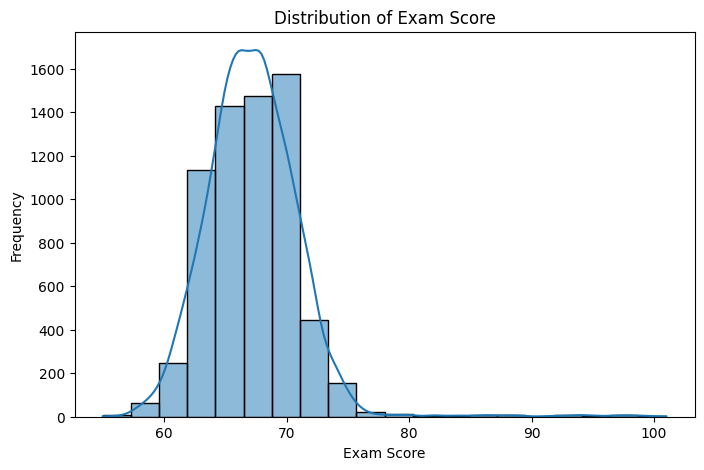

Mean   : 67.24
Median : 67.00
Std    : 3.89


In [ ]:
# Distribution of exam score

plt.figure(figsize=(8,5))

sns.histplot(
    df["Exam_Score"],
    bins=20,
    kde=True
)

plt.title("Distribution of Exam Score")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")

plt.show()

print(f"Mean   : {df['Exam_Score'].mean():.2f}")
print(f"Median : {df['Exam_Score'].median():.2f}")
print(f"Std    : {df['Exam_Score'].std():.2f}")

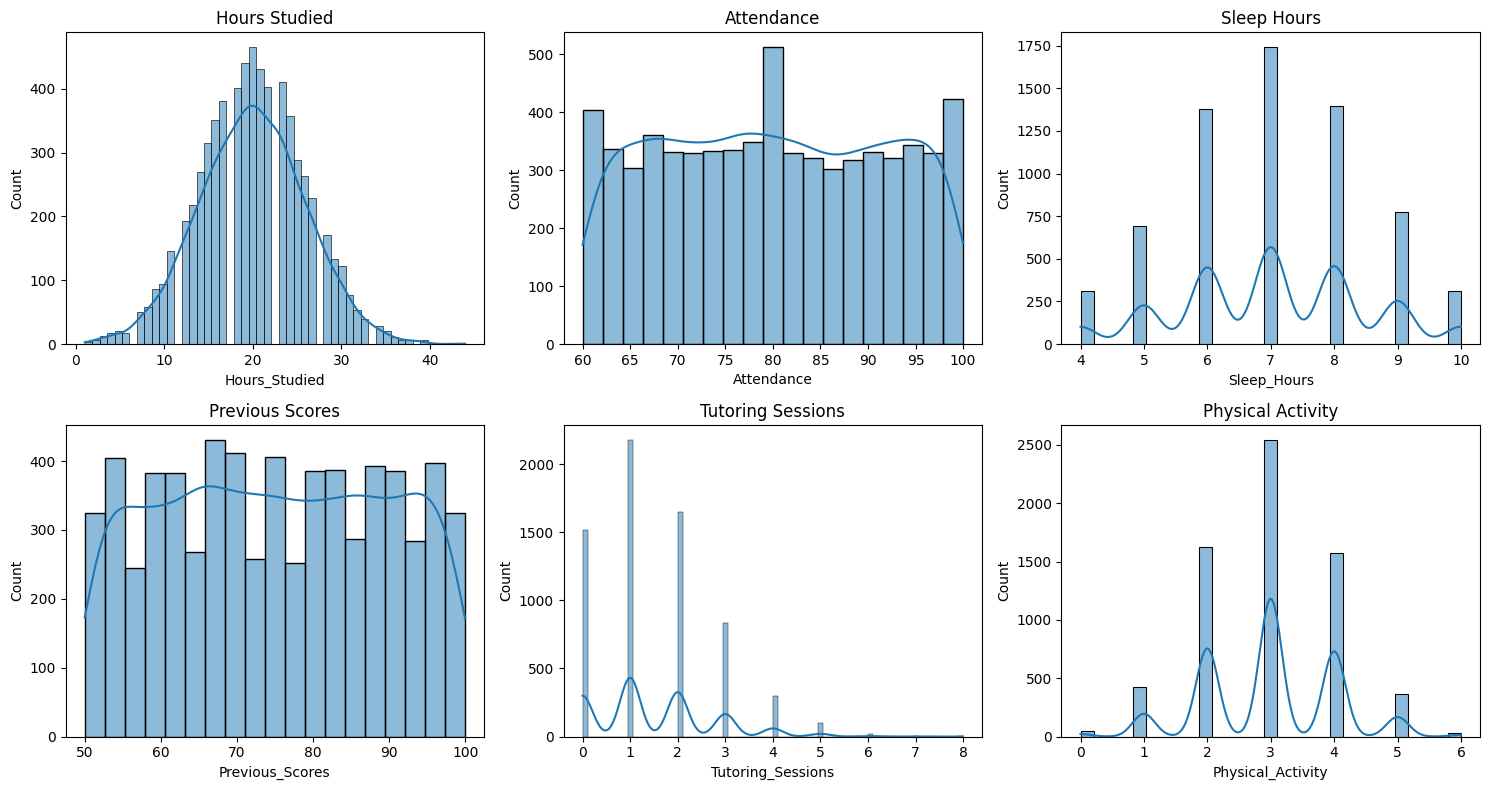

In [ ]:
# Distribution of numerical features

numerical_features = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_features):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(col.replace("_", " "))

plt.tight_layout()
plt.show()

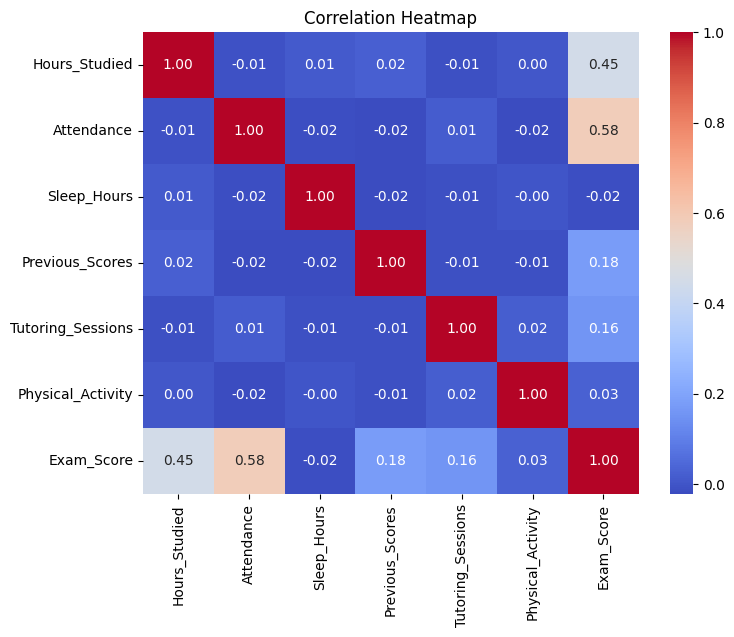

In [ ]:
# Correlation heatmap

plt.figure(figsize=(8,6))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

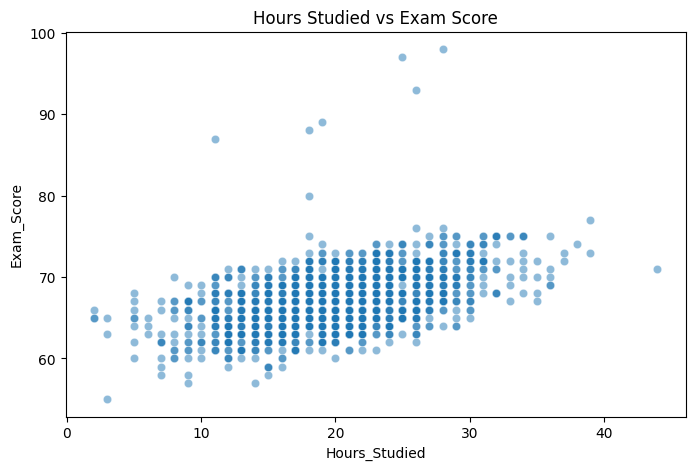

In [ ]:
# Hours studied vs exam score

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(1500, random_state=42),
    x="Hours_Studied",
    y="Exam_Score",
    alpha=0.5
)
plt.title("Hours Studied vs Exam Score")

plt.show()

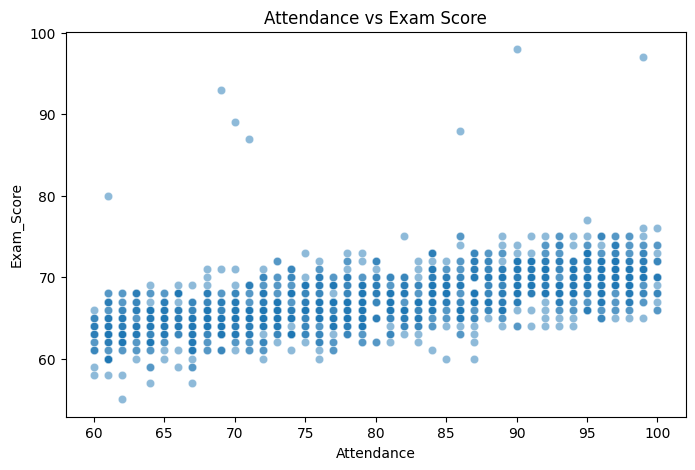

In [ ]:
# Attendance vs exam score

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(1500, random_state=42),
    x="Attendance",
    y="Exam_Score",
    alpha=0.5
)

plt.title("Attendance vs Exam Score")

plt.show()

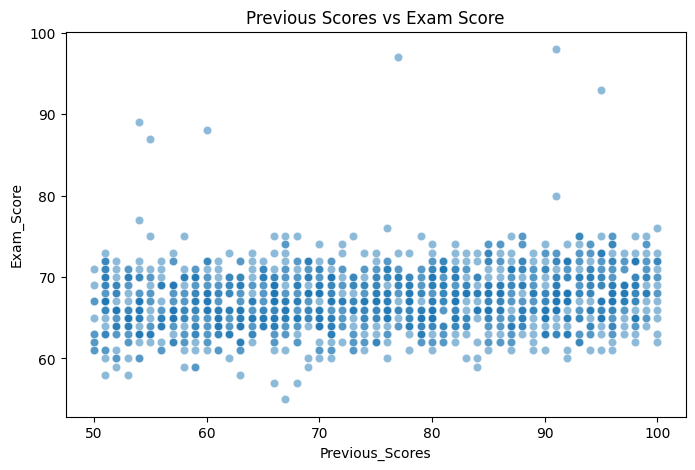

In [ ]:
# Previous scores vs exam score

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(1500, random_state=42),
    x="Previous_Scores",
    y="Exam_Score",
    alpha=0.5
)

plt.title("Previous Scores vs Exam Score")

plt.show()

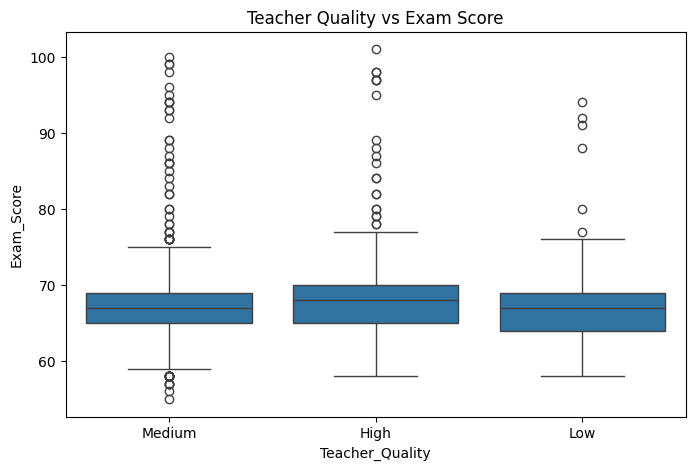

In [ ]:
# Teacher quality vs exam score

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Teacher_Quality",
    y="Exam_Score"
)

plt.title("Teacher Quality vs Exam Score")

plt.show()

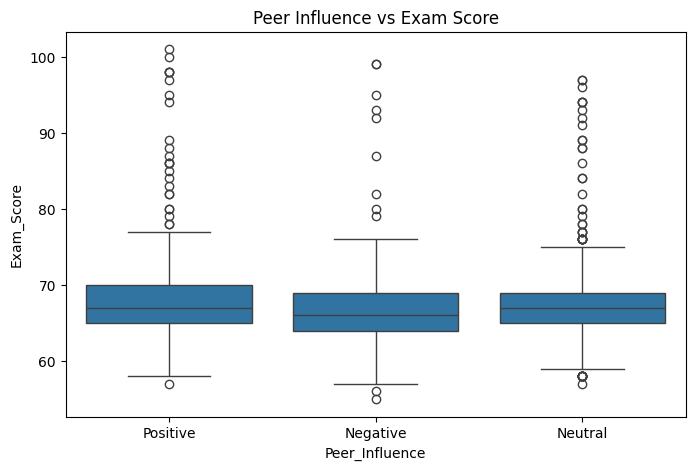

In [ ]:
# Peer influence vs exam score

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Peer_Influence",
    y="Exam_Score"
)

plt.title("Peer Influence vs Exam Score")

plt.show()

In [ ]:
#Key Insight

corr_exam = (
    df.corr(numeric_only=True)["Exam_Score"]
    .sort_values(ascending=False)
)

display(corr_exam.to_frame("Correlation"))

,Correlation
Exam_Score,1.000000
Attendance,0.581072
Hours_Studied,0.445455
Previous_Scores,0.175079
Tutoring_Sessions,0.156525
Physical_Activity,0.027824
Sleep_Hours,-0.017022


# Data Preparation

In [ ]:
# Data cleaning

df_prep = df.copy()

outlier_score = (df_prep["Exam_Score"] > 100).sum()

print(
    f"Jumlah nilai Exam_Score > 100 : {outlier_score}"
)

df_prep["Exam_Score"] = df_prep[
    "Exam_Score"
].clip(upper=100)

print(
    f"Nilai maksimum Exam_Score setelah cleaning : "
    f"{df_prep['Exam_Score'].max()}"
)

Jumlah nilai Exam_Score > 100 : 1
Nilai maksimum Exam_Score setelah cleaning : 100


In [ ]:
# Handle missing values

missing_cols = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

for col in missing_cols:

    df_prep[col] = df_prep[col].fillna(
        df_prep[col].mode()[0]
    )

print(
    "Remaining Missing Values :",
    df_prep.isnull().sum().sum()
)
print(
    "Dataset Shape :",
    df_prep.shape
)

Remaining Missing Values : 0
Dataset Shape : (6607, 20)


In [ ]:
# Create performance category

df_prep["Performance_Category"] = pd.qcut(
    df_prep["Exam_Score"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print(
    df_prep["Performance_Category"]
    .value_counts()
)

Performance_Category
Low       2882
Medium    2100
High      1625
Name: count, dtype: int64


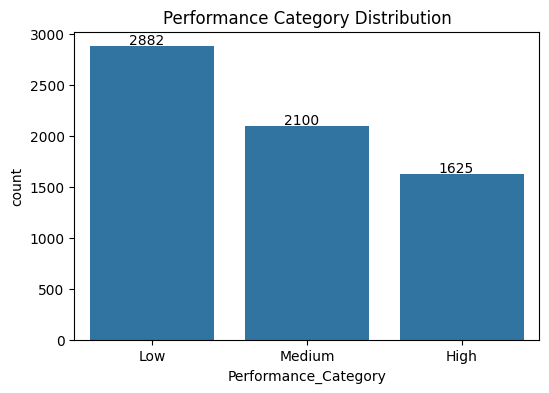

In [ ]:
# Performance category distribution

plt.figure(figsize=(6,4))
ax = sns.countplot(
    data=df_prep,
    x="Performance_Category",
    order=["Low","Medium","High"]
)
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x()+0.25,p.get_height()+20))

plt.title("Performance Category Distribution")
plt.show()
plt.show()

In [ ]:
# Encode categorical features

from sklearn.preprocessing import LabelEncoder
df_encoded = df_prep.copy()
label_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2}
df_encoded["Target"] = (
    df_encoded["Performance_Category"]
    .map(label_map))
encoders = {}
cat_cols = (
    df_encoded
    .select_dtypes(include="object")
    .columns
    .tolist())
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(
    df_encoded[col].astype(str))
    encoders[col] = le

display(df_encoded.head())
print("Encoded Dataset Shape :", df_encoded.shape)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Performance_Category,Target
0,23,84,1,0,0,7,73,1,1,0,...,1,2,3,0,1,2,1,67,Medium,1
1,19,64,1,2,0,8,59,1,1,2,...,1,0,4,0,0,1,0,61,Low,0
2,24,98,2,2,1,7,91,2,1,2,...,1,1,4,0,2,2,1,74,High,2
3,29,89,1,2,1,8,98,2,1,1,...,1,0,4,0,1,1,1,71,High,2
4,19,92,2,2,1,6,65,2,1,3,...,1,1,4,0,0,2,0,70,High,2


Encoded Dataset Shape : (6607, 22)


In [ ]:
# Define features and target

exclude_cols = [
    "Exam_Score",
    "Performance_Category",
    "Target"]
feature_cols = [
    col
    for col in df_encoded.columns
    if col not in exclude_cols]
X = df_encoded[feature_cols]
y = df_encoded["Target"]

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (6607, 19)
y Shape : (6607,)


In [ ]:
# Train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (5285, 19)
Testing Set  : (1322, 19)


In [ ]:
# Class distribution

print("Training Distribution")
print(y_train.value_counts(normalize=True))

print("\nTesting Distribution")
print(y_test.value_counts(normalize=True))

Training Distribution
Target
0    0.436140
1    0.317881
2    0.245979
Name: proportion, dtype: float64

Testing Distribution
Target
0    0.43646
1    0.31770
2    0.24584
Name: proportion, dtype: float64


In [ ]:
# Feature scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(
    X_train)
X_test_scaled = scaler.transform(
    X_test)
print("Scaling completed")
print("\nTrain Shape :", X_train_scaled.shape)
print("Test Shape  :", X_test_scaled.shape)
print("Number of Features :", X_train.shape[1])

Scaling completed

Train Shape : (5285, 19)
Test Shape  : (1322, 19)
Number of Features : 19


# Classification

In [ ]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report)

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42)

lr_model.fit( X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled
)

print(
    "Training Accuracy :",
    round(lr_model.score(X_train_scaled,y_train),
        4 ))

print("Testing Accuracy  :",
round(accuracy_score(y_test,y_pred_lr),4))

Training Accuracy : 0.8259
Testing Accuracy  : 0.8011


              precision    recall  f1-score   support

         Low       0.87      0.86      0.86       577
      Medium       0.69      0.72      0.70       420
        High       0.83      0.81      0.82       325

    accuracy                           0.80      1322
   macro avg       0.80      0.79      0.80      1322
weighted avg       0.80      0.80      0.80      1322



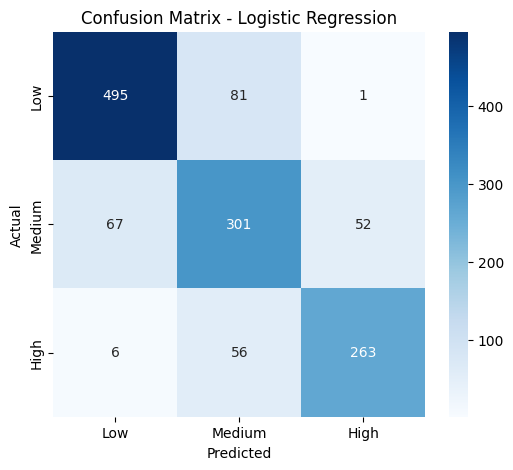

In [ ]:
# Evaluation Logistic Regression

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

rec_lr = recall_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Low","Medium","High"]
))

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low","Medium","High"],
    yticklabels=["Low","Medium","High"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test
)

y_proba_rf = rf_model.predict_proba(
    X_test
)

print("Training Accuracy :",
      round(rf_model.score(X_train, y_train), 4))

print("Testing Accuracy  :",
      round(accuracy_score(y_test, y_pred_rf), 4))

Training Accuracy : 0.9949
Testing Accuracy  : 0.8056


              precision    recall  f1-score   support

         Low       0.88      0.87      0.88       577
      Medium       0.69      0.73      0.71       420
        High       0.84      0.78      0.81       325

    accuracy                           0.81      1322
   macro avg       0.80      0.80      0.80      1322
weighted avg       0.81      0.81      0.81      1322



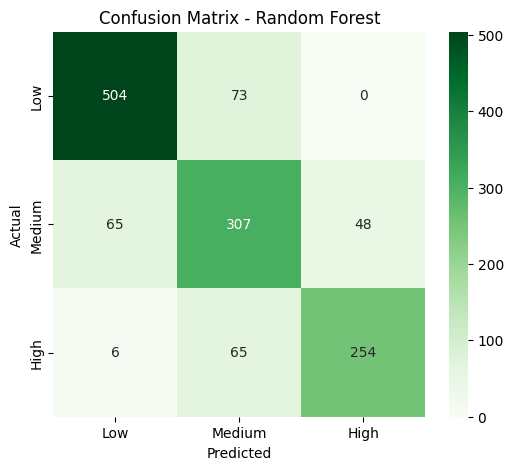

In [ ]:
# Evaluation Random Forest

acc_rf = accuracy_score(y_test, y_pred_rf)

prec_rf = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rec_rf = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Low","Medium","High"]
))

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Low","Medium","High"],
    yticklabels=["Low","Medium","High"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# XGBoost

xgb_model = XGBClassifier(
    n_estimators=250,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    eval_metric="mlogloss",
    random_state=42
)
xgb_model.fit(
    X_train,
    y_train
)

y_pred_xgb = xgb_model.predict(
    X_test
)

y_proba_xgb = xgb_model.predict_proba(
    X_test
)

print("Training Accuracy :",
      round(xgb_model.score(X_train, y_train), 4))

print("Testing Accuracy  :",
      round(accuracy_score(y_test, y_pred_xgb), 4))

Training Accuracy : 0.9949
Testing Accuracy  : 0.8759


              precision    recall  f1-score   support

         Low       0.93      0.92      0.92       577
      Medium       0.79      0.86      0.82       420
        High       0.91      0.82      0.87       325

    accuracy                           0.88      1322
   macro avg       0.88      0.87      0.87      1322
weighted avg       0.88      0.88      0.88      1322



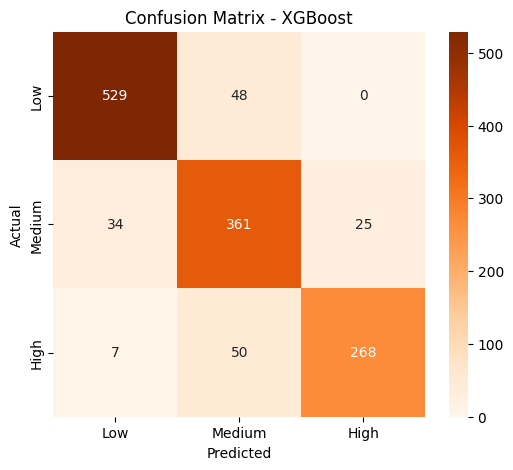

In [ ]:
# Evaluation XGBoost

acc_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

prec_xgb = precision_score(
    y_test,
    y_pred_xgb,
    average="weighted"
)

rec_xgb = recall_score(
    y_test,
    y_pred_xgb,
    average="weighted"
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb,
    average="weighted"
)

print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["Low","Medium","High"]
))

cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Low","Medium","High"],
    yticklabels=["Low","Medium","High"]
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# Model comparison

comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],'Accuracy': [acc_lr,acc_rf,acc_xgb],
    'Precision': [prec_lr,prec_rf,prec_xgb],
    'Recall': [rec_lr, rec_rf,rec_xgb],
    'F1 Score': [f1_lr, f1_rf,f1_xgb]
})
comparison_df = comparison_df.sort_values(
by='F1 Score',ascending=False)
comparison_df.reset_index(
drop=True, inplace=True
)
display( comparison_df.round(4))
best_model_name = comparison_df.iloc[0]['Model']
print(f"Best Model : {best_model_name}")

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.8759,0.8798,0.8759,0.8768
1,Random Forest,0.8056,0.8085,0.8056,0.8066
2,Logistic Regression,0.8011,0.8033,0.8011,0.8020


Best Model : XGBoost


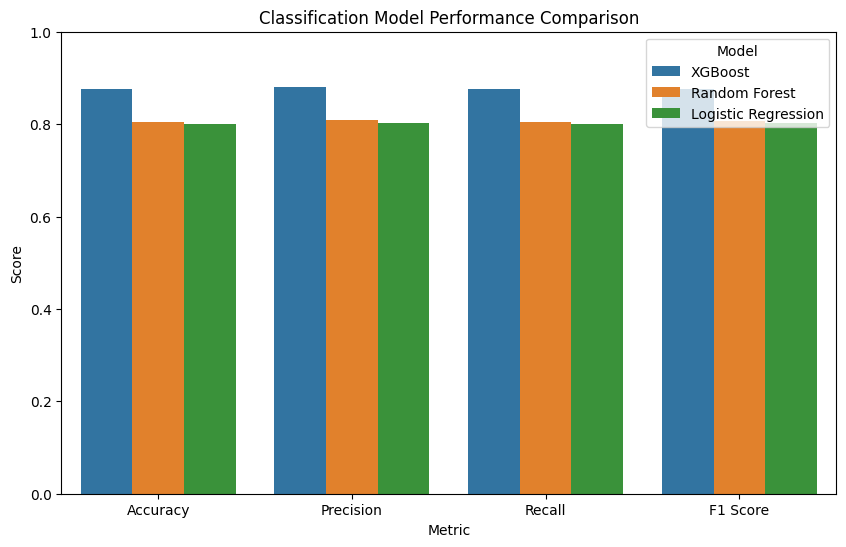

In [ ]:
# Performance comparison chart

comparison_melted = comparison_df.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison_melted,
    x='Metric',
    y='Score',
    hue='Model'
)

plt.title('Classification Model Performance Comparison')

plt.ylim(0, 1)

plt.show()

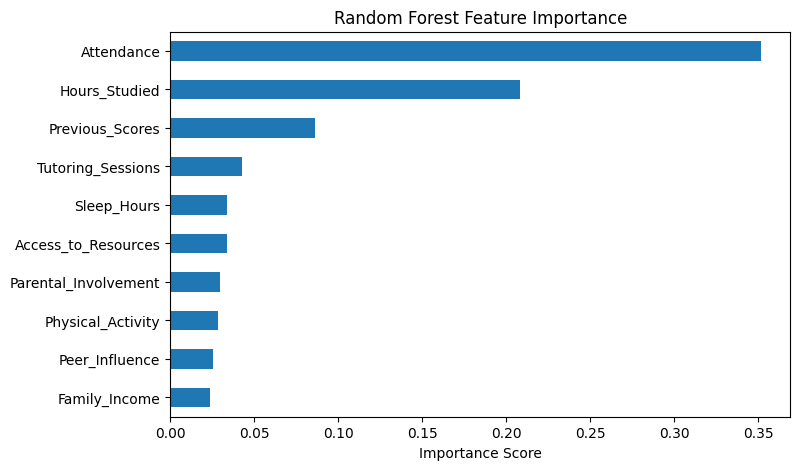

,0
Attendance,0.351514
Hours_Studied,0.208368
Previous_Scores,0.086046
Tutoring_Sessions,0.042674
Sleep_Hours,0.033839
Access_to_Resources,0.033505
Parental_Involvement,0.029585
Physical_Activity,0.028379
Peer_Influence,0.025257
Family_Income,0.023412


In [ ]:
# Random Forest feature importance

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(
    ascending=True
)
plt.figure(figsize=(8,5))
rf_importance.tail(10).plot(
    kind="barh")
plt.title(
    "Random Forest Feature Importance")
plt.xlabel(
    "Importance Score")
plt.show()
display(
    rf_importance
    .sort_values(
        ascending=False)
    .head(10))

In [ ]:
# Best model summary

print("Best Model :", best_model_name)
print("Accuracy :", round(acc_xgb,4))
print("F1 Score :", round(f1_xgb,4))

Best Model : XGBoost
Accuracy : 0.8759
F1 Score : 0.8768


# Clustering

In [ ]:
# Clustering preparation

from sklearn.preprocessing import StandardScaler

scaler_cluster = StandardScaler()

X_scaled = pd.DataFrame(
    scaler_cluster.fit_transform(X),
    columns=X.columns
)

X_cluster = X_scaled.copy()

print("Shape :", X_cluster.shape)
print("Features :", X_cluster.shape[1])
print("Records :", X_cluster.shape[0])

Shape : (6607, 19)
Features : 19
Records : 6607


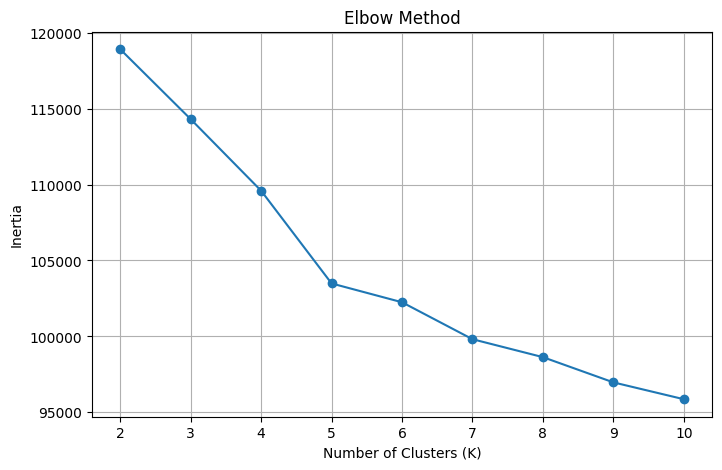

In [ ]:
# Elbow method

from sklearn.cluster import KMeans

k_values = range(2, 11)

inertia_values = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster)

    inertia_values.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

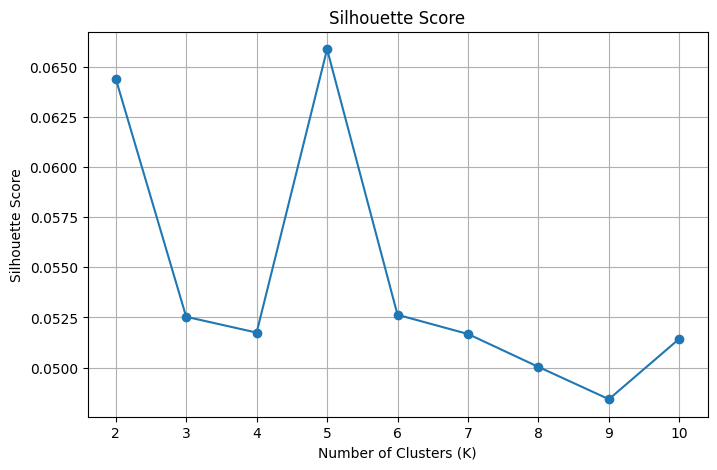

,K,Inertia,Silhouette Score
0,2,118909.666681,0.064414
1,3,114306.474747,0.052534
2,4,109593.440360,0.051745
3,5,103488.594352,0.065874
4,6,102249.781259,0.052632
5,7,99817.314860,0.051674
6,8,98635.461461,0.050034
7,9,96974.807385,0.048422
8,10,95865.847589,0.051439


Best K : 5


In [ ]:
# Silhouette score

from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)
    labels = kmeans.fit_predict(
        X_cluster)
    score = silhouette_score(
        X_cluster,
        labels)
    silhouette_scores.append(score)
plt.figure(figsize=(8,5))
plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.grid(True)
plt.show()

# Clustering evaluation

cluster_eval = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_values,
    "Silhouette Score": silhouette_scores})
display(cluster_eval)
best_k = k_values[
    np.argmax(silhouette_scores)]

print("Best K :", best_k)

In [ ]:
# K-Means clustering

kmeans_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)
cluster_labels = kmeans_model.fit_predict(
    X_cluster
)
print(
    pd.Series(cluster_labels)
    .value_counts()
    .sort_index()
)

0     646
1    1652
2    2208
3    1602
4     499
Name: count, dtype: int64


In [ ]:
# Add cluster label

df_clustered = df_prep.copy()

df_clustered["Cluster"] = cluster_labels

print(df_clustered.columns.tolist())

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score', 'Performance_Category', 'Cluster']


In [ ]:
# Cluster profile

cluster_profile = (
    df_clustered
    .groupby("Cluster")
    .mean(numeric_only=True)
    .round(2)
)

display(cluster_profile)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Cluster,,,,,,,
0,19.78,79.23,7.11,75.38,1.54,3.00,66.37
1,20.02,80.44,7.01,74.73,1.47,2.97,67.47
2,19.97,79.88,7.05,75.24,1.49,2.97,67.38
3,20.05,79.71,7.01,75.13,1.49,2.93,67.36
4,19.87,80.72,6.97,74.85,1.54,3.01,66.53


Performance_Category,Low,Medium,High
Cluster,,,
0,0.529,0.293,0.178
1,0.406,0.328,0.266
2,0.412,0.329,0.260
3,0.434,0.310,0.256
4,0.531,0.293,0.176


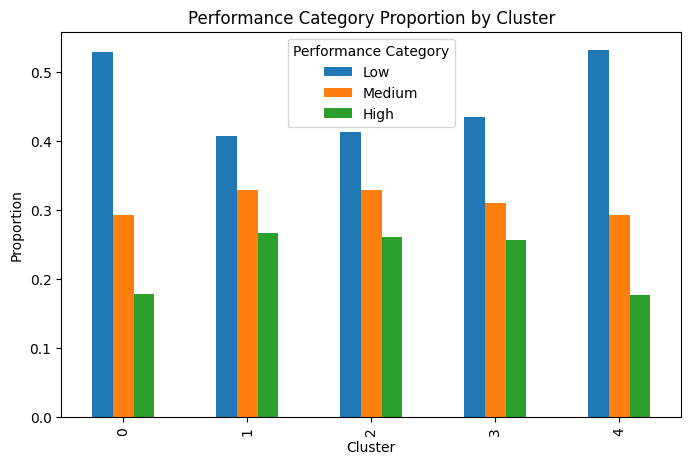

In [ ]:
# Performance category proportion by cluster

cluster_perf_pct = pd.crosstab(
    df_clustered["Cluster"],
    df_clustered["Performance_Category"],
    normalize="index"
).round(3)
display(cluster_perf_pct)
cluster_perf_pct.plot(
    kind="bar",
    figsize=(8,5))
plt.title(
    "Performance Category Proportion by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proportion")
plt.legend(
    title="Performance Category")

plt.show()

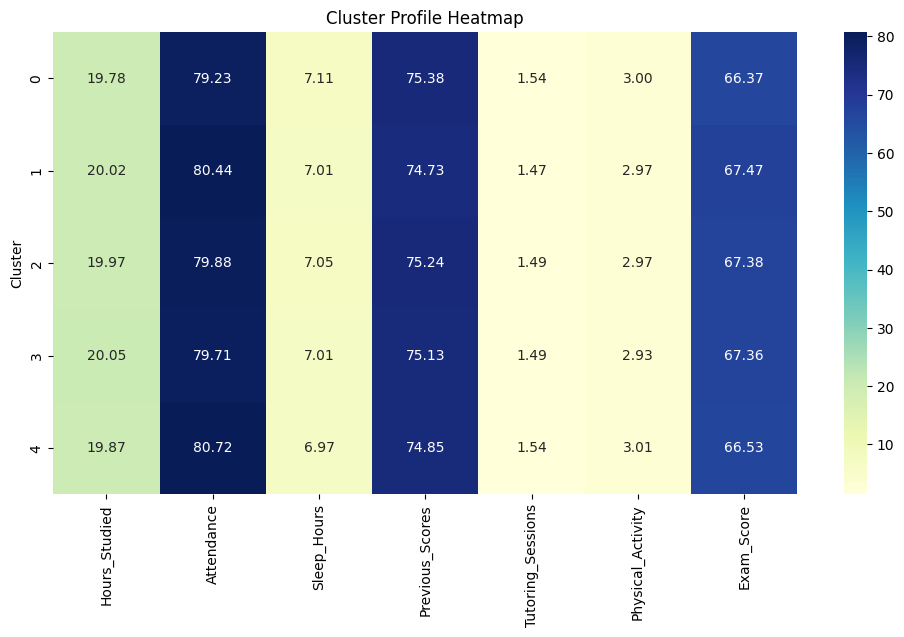

In [ ]:
# Heatmap cluster profile

plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title(
    "Cluster Profile Heatmap"
)

plt.show()

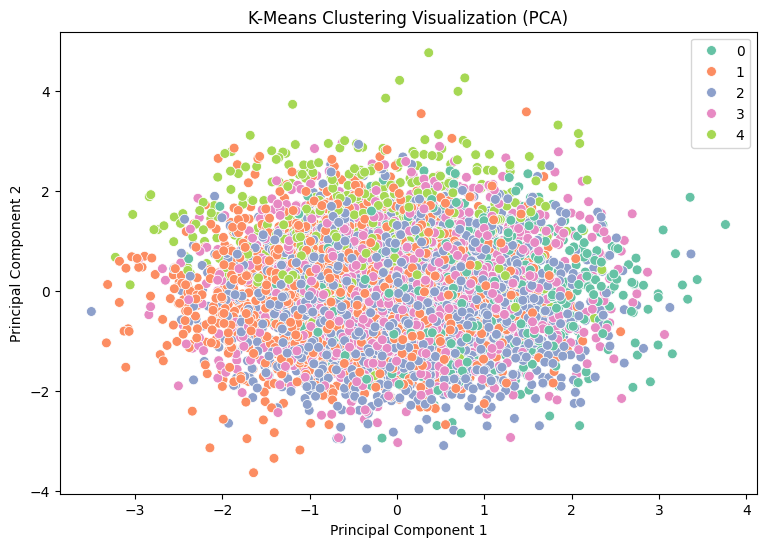

In [ ]:
# PCA visualization

from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_cluster
)

plt.figure(figsize=(9,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=cluster_labels,
    palette="Set2",
    s=50
)

plt.title(
    "K-Means Clustering Visualization (PCA)"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

# Explainable AI (SHAP)

In [ ]:
# SHAP preparation

import shap

print("SHAP Version :", shap.__version__)
explainer = shap.TreeExplainer(
    xgb_model
)

print("SHAP Explainer Created")

SHAP Version : 0.52.0
SHAP Explainer Created


In [ ]:
# Calculate SHAP values

sample_size = min(
    500,
    len(X_test_scaled)
)

X_shap = pd.DataFrame(
    X_test_scaled[:sample_size],
    columns=X.columns
)

shap_values = explainer.shap_values(
    X_shap
)

print("Sample Size :", sample_size)

Sample Size : 500


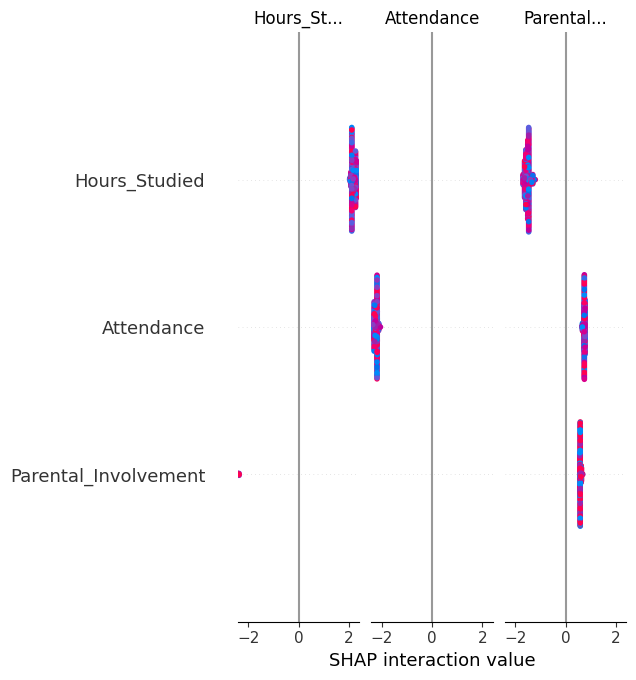

In [ ]:
# SHAP summary plot

if isinstance(shap_values, list):
    shap.summary_plot(shap_values[2],X_shap)
else:
    shap.summary_plot(shap_values,X_shap)

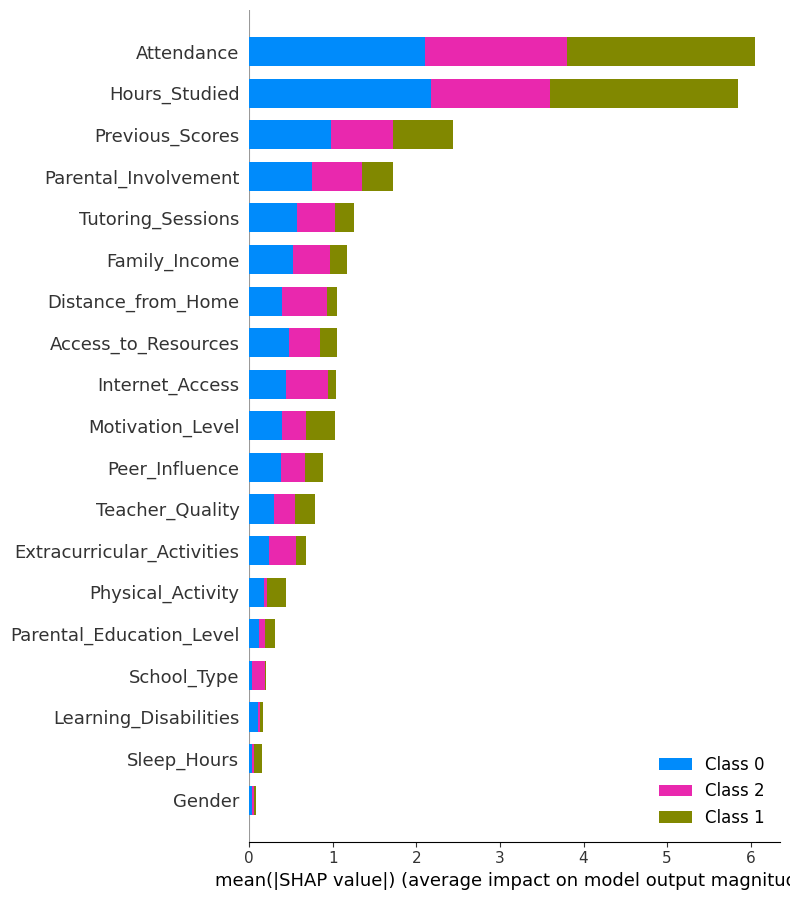

In [ ]:
# SHAP bar plot

if isinstance(shap_values, list):
    shap.summary_plot(
        shap_values[2],
        X_shap,
        plot_type="bar")
else:
    shap.summary_plot(
        shap_values,
        X_shap,
        plot_type="bar")

In [ ]:
# SHAP feature ranking

mean_abs_shap = np.abs(
    shap_values
).mean(axis=(0,2))

shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "SHAP_Value": mean_abs_shap
})

shap_importance = (
    shap_importance
    .sort_values(
        by="SHAP_Value",
        ascending=False
    )
)

display(
    shap_importance.head(10)
)

,Feature,SHAP_Value
1,Attendance,2.016216
0,Hours_Studied,1.950061
6,Previous_Scores,0.814691
2,Parental_Involvement,0.573887
9,Tutoring_Sessions,0.417120
10,Family_Income,0.389631
17,Distance_from_Home,0.350727
3,Access_to_Resources,0.349637
8,Internet_Access,0.346515
7,Motivation_Level,0.343039


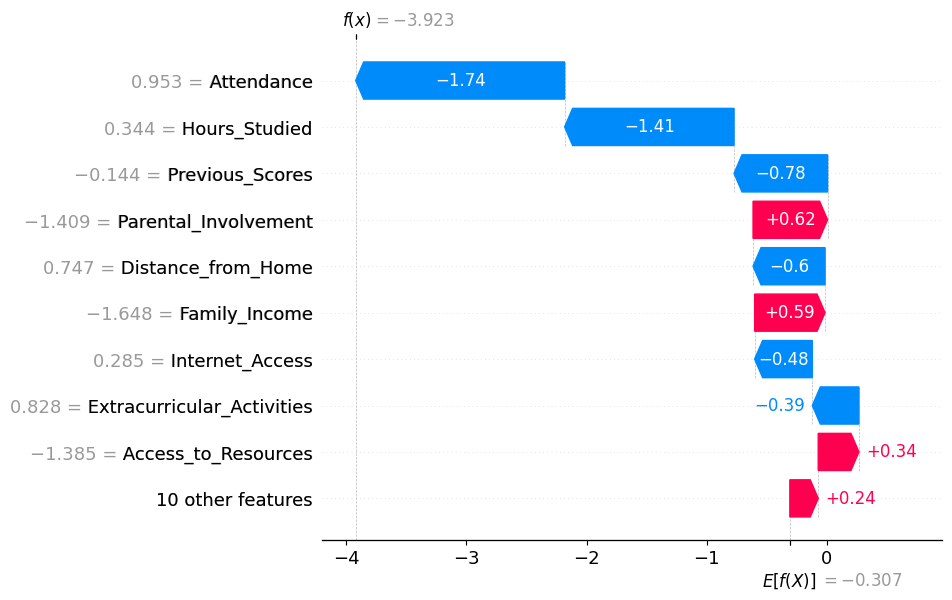

In [ ]:
# SHAP waterfall plot

sample_idx = 0
class_idx = 2

shap_exp = shap.Explanation(
    values=shap_values[sample_idx, :, class_idx],
    base_values=explainer.expected_value[class_idx],
    data=X_shap.iloc[sample_idx],
    feature_names=X_shap.columns
)

shap.waterfall_plot(shap_exp)

#Deployment Preparation

In [ ]:
# Save Model

import os
import joblib

os.makedirs("model", exist_ok=True)

joblib.dump(
    xgb_model,
    "model/xgboost_model.pkl"
)

joblib.dump(
    kmeans_model,
    "model/kmeans_model.pkl"
)

joblib.dump(
    scaler,
    "model/scaler.pkl"
)

joblib.dump(
    encoders,
    "model/encoders.pkl"
)

print("Model berhasil disimpan")

Model berhasil disimpan


In [ ]:
# Save metadata

metadata = {
    "feature_names": X.columns.tolist(),
    "label_map": {
        0: "Low",
        1: "Medium",
        2: "High"
    }
}

joblib.dump(
    metadata,
    "model/metadata.pkl"
)

print(
    "Metadata saved"
)

Metadata saved


In [ ]:
# Verify saved files

import os

for file in os.listdir("model"):
    print(file)

encoders.pkl
kmeans_model.pkl
xgboost_model.pkl
scaler.pkl
metadata.pkl


In [ ]:
# Deployment summary

print("Classification Model : XGBoost")
print("Clustering Model : K-Means")
print(
    "Number of Features :",
    len(metadata["feature_names"]))

Classification Model : XGBoost
Clustering Model : K-Means
Number of Features : 19


# Load Model


In [ ]:
# Load saved model

xgb_loaded = joblib.load(
    "model/xgboost_model.pkl"
)

scaler_loaded = joblib.load(
    "model/scaler.pkl"
)

metadata_loaded = joblib.load(
    "model/metadata.pkl"
)

print("All files loaded")

All files loaded


In [ ]:
def predict_student(input_data):
    input_df = pd.DataFrame(
        [input_data]
    )

    input_df = input_df[
        metadata_loaded["feature_names"]
    ]

    input_scaled = scaler_loaded.transform(
        input_df
    )

    prediction = int(
        xgb_loaded.predict(input_scaled)[0]
    )

    probability = (
        xgb_loaded.predict_proba(
            input_scaled
        )[0]
    )

    result = metadata_loaded[
        "label_map"
    ][prediction]

    confidence = round(
        float(np.max(probability)) * 100,
        2
    )

    return {
        "Prediction": result,
        "Confidence": confidence
    }

In [ ]:
# Example prediction

sample_student = X.iloc[0].to_dict()

predict_student(
    sample_student
)

{'Prediction': 'Low', 'Confidence': 99.97}